# Inicialização e preparação


In [ ]:
import os
import glob
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.environ["LANG"] = "en_US.UTF-8"

def here(*args):
    return os.path.join(os.getcwd(), *args)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def f_loadFiles(files_list):
# =====================================================================
# Le o csv e concatena
# =====================================================================
    temp = []
    for filename in files_list:
        try:
            # Para evitar problemas com encodings gerados pelo R ou Excel
            df = pd.read_csv(filename, encoding="utf-8")
            temp.append(df)
        except Exception:
            try:
                # Contingência caso o arquivo tenha caracteres latinos/especiais
                df = pd.read_csv(filename, encoding="latin1")
                temp.append(df)
            except Exception:
                continue
    if temp:
        return pd.concat(temp, ignore_index=True)
    return pd.DataFrame()


def rename_variables(df):
    """Mapeia os nomes antigos de variáveis de saída agrícolas

    para a nomenclatura padronizada e atualizada.
    """
    if "variable" not in df.columns:
        return df

    mapping = {
        "CWAD": "Biomass_abv",
        "TOPW": "Biomass_abv",
        "msa": "Biomass_abv",
        "ETAA": "ET",
        "LPIF": "fSolar",
        "LIF": "fSolar",
        "PWAD": "Biomass_REP",
        "HWAD": "Biomass_GRAIN",
        "GWAD": "Biomass_GRAIN",
        "SWAD": "Biomass_STEM",
        "GSTEMW": "Biomass_STEM",
        "STEM": "Biomass_STEM",
        "mstu": "Biomass_STEM",
        "SWRZ": "SWAZ",
        "GLEAFW": "Biomass_GLEAVES",
        "GLEAF": "Biomass_GLEAVES",
        "LWAD": "Biomass_GLEAVES",
        "mslv": "Biomass_GLEAVES",
        "TOPDW": "Biomass_DLEAVES",
        "DLEAF": "Biomass_DLEAVES",
        "LWADEC": "Biomass_DLEAVES",
        "cycle": "CYCLE",
        "GLAI": "LAID",
        "lai": "LAID",
    }
    df["variable"] = df["variable"].replace(mapping)
    return df


def calc_metrics(df, group_vars):

    def agg_func(g):
        me = g["error"].mean()
        rmse = np.sqrt((g["sq_error"]).mean())
        rmse_rel = rmse / g["obs"].mean() if g["obs"].mean() != 0 else np.nan
        mae = g["abs_error"].mean()
        mae_rel = (
            (mae * 100) / g["obs"].mean() if g["obs"].mean() != 0 else np.nan
        )

        mean_obs = g["mean_obs"].mean()
        mean_simul = g["mean_simul"].mean()

        # nse1 e d1_ (Métricas Yang et al. 2014)
        denom_nse1 = np.abs(g["obs"] - mean_obs).sum()
        nse1 = (
            1 - (g["abs_error"].sum() / denom_nse1)
            if denom_nse1 != 0
            else np.nan
        )
        d1_ = (
            1 - (g["abs_error"].sum() / (2 * denom_nse1))
            if denom_nse1 != 0
            else np.nan
        )

        # nse e d clássicos
        denom_nse = ((g["obs"] - mean_obs) ** 2).sum()
        nse = 1 - (g["sq_error"].sum() / denom_nse) if denom_nse != 0 else np.nan

        denom_d = (
            (np.abs(g["simul"] - mean_obs) + np.abs(g["obs"] - mean_obs)) ** 2
        ).sum()
        d = 1 - (g["sq_error"].sum() / denom_d) if denom_d != 0 else np.nan

        return pd.Series(
            {
                "me": me,
                "rmse": rmse,
                "rmse_rel": rmse_rel,
                "mae": mae,
                "mae_rel": mae_rel,
                "mean_obs": mean_obs,
                "mean_simul": mean_simul,
                "nse1": nse1,
                "d1_": d1_,
                "nse": nse,
                "d": d,
            }
        )

    # Executa a agregação (ajustado para evitar warnings de deprecation do pandas)
    res = df.groupby(group_vars, group_keys=False).apply(agg_func).reset_index()

    # Arredondamentos numéricos gerais
    num_cols = res.select_dtypes(include=[np.number]).columns
    res[num_cols] = res[num_cols].round(4)
    if "mae_rel" in res.columns:
        res["mae_rel"] = res["mae_rel"].round(2)

    # Regra de arredondamento específica por tipo de variável da cultura
    for col in ["mae", "me", "rmse", "mean_simul", "mean_obs"]:
        if col in res.columns and "variable" in res.columns:
            res[col] = res.apply(
                lambda r: (
                    round(r[col], 0)
                    if r["variable"] not in ["LAID", "GPP", "ET"]
                    else round(r[col], 4)
                ),
                axis=1,
            )
    return res


def remove_results(crop, paths=None):
    """Limpa com segurança arquivos antigos de simulação e figuras

    para evitar confusão de resultados antigos no Google Drive.
    """
    if paths is None:
        # Usa a função here() que definimos para o Drive
        paths = [here("figures", crop, ""), here("outputs", crop, "")]

    for p in paths:
        if os.path.exists(p):
            files = glob.glob(os.path.join(p, "*"))
            for f in files:
                if os.path.isfile(f):
                    try:
                        os.unlink(f)
                    except Exception:
                        continue
            print(f"🧹 Pasta limpa no Drive: {p}")


def new_crop(crop):
    """Cria recursivamente toda a árvore de diretórios necessária

    para uma nova cultura direto na raiz mapeada do Drive.
    """
    list_paths = [
        here("inputs", crop, ""),
        here("inputs", "weather", ""),
        here("figures", ""),
        here("figures", crop, ""),
        here("outputs", ""),
        here("outputs", crop, ""),
    ]
    for folder in list_paths:
        os.makedirs(folder, exist_ok=True)
    print(
        f"📁 Estrutura de pastas para '{crop}' criada/verificada com sucesso no Google Drive!"
    )

## Rodar o Pós processamento, com dados do Drive

In [ ]:
def rename_variables(df):
    """Mapeia os nomes brutos de saídas do AgS para a nomenclatura atualizada."""
    if "variable" not in df.columns:
        return df

    mapping = {
        "CWAD": "Biomass_abv", "TOPW": "Biomass_abv", "msa": "Biomass_abv",
        "ETAA": "ET", "LPIF": "fSolar", "LIF": "fSolar", "PWAD": "Biomass_REP",
        "HWAD": "Biomass_GRAIN", "GWAD": "Biomass_GRAIN", "SWAD": "Biomass_STEM",
        "GSTEMW": "Biomass_STEM", "STEM": "Biomass_STEM", "mstu": "Biomass_STEM",
        "SWRZ": "SWAZ", "GLEAFW": "Biomass_GLEAVES", "GLEAF": "Biomass_GLEAVES",
        "LWAD": "Biomass_GLEAVES", "mslv": "Biomass_GLEAVES", "TOPDW": "Biomass_DLEAVES",
        "DLEAF": "Biomass_DLEAVES", "LWADEC": "Biomass_DLEAVES", "cycle": "CYCLE",
        "GLAI": "LAID", "lai": "LAID"
    }
    df["variable"] = df["variable"].replace(mapping)
    return df

In [ ]:
import numpy as np

def calc_metrics(df, group_vars):
    """Calcula estatísticas clássicas e Yang et al. (2014) com regras do R."""

    def agg_func(g):
        obs_mean = g["obs"].mean()
        me = g["error"].mean()
        rmse = np.sqrt((g["sq_error"]).mean())
        rmse_rel = rmse / obs_mean if obs_mean != 0 else np.nan
        mae = g["abs_error"].mean()
        mae_rel = (mae * 100) / obs_mean if obs_mean != 0 else np.nan

        mean_obs, mean_simul = g["mean_obs"].mean(), g["mean_simul"].mean()
        denom_nse1 = np.abs(g["obs"] - mean_obs).sum()

        nse1 = 1 - (g["abs_error"].sum() / denom_nse1) if denom_nse1 != 0 else np.nan
        d1_ = 1 - (g["abs_error"].sum() / (2 * denom_nse1)) if denom_nse1 != 0 else np.nan

        denom_nse = ((g["obs"] - mean_obs) ** 2).sum()
        nse = 1 - (g["sq_error"].sum() / denom_nse) if denom_nse != 0 else np.nan

        denom_d = ((np.abs(g["simul"] - mean_obs) + np.abs(g["obs"] - mean_obs)) ** 2).sum()
        d = 1 - (g["sq_error"].sum() / denom_d) if denom_d != 0 else np.nan

        return pd.Series({
            "me": me, "rmse": rmse, "rmse_rel": rmse_rel, "mae": mae, "mae_rel": mae_rel,
            "mean_obs": mean_obs, "mean_simul": mean_simul, "nse1": nse1, "d1_": d1_, "nse": nse, "d": d
        })

    res = df.groupby(group_vars, group_keys=False).apply(agg_func).reset_index()

    # Arredondamentos numéricos baseados nas variáveis
    num_cols = res.select_dtypes(include=[np.number]).columns
    res[num_cols] = res[num_cols].round(4)
    if "mae_rel" in res.columns:
        res["mae_rel"] = res["mae_rel"].round(2)

    for col in ["mae", "me", "rmse", "mean_simul", "mean_obs"]:
        if col in res.columns and "variable" in res.columns:
            res[col] = res.apply(
                lambda r: round(r[col], 0) if r["variable"] not in ["LAID", "GPP", "ET"] else round(r[col], 4),
                axis=1
            )
    return res

In [ ]:
import os
import pandas as pd

# 1. Caminho do seu output salvo no Drive
path_outputs_prontos = "/content/drive/MyDrive/MESTRADO/Embrapa/parciais/MarchacomAgs.csv"

print(f"Lendo o arquivo de simulação em: {path_outputs_prontos}")

# 2. Carregando com pandas (verificando separador vírgula ou ponto e vírgula)
try:
    df_bruto = pd.read_csv(path_outputs_prontos, encoding="utf-8", sep=",")
    df_bruto.columns = df_bruto.columns.str.lower()
    if len(df_bruto.columns) < 10: # Se carregou tudo em 1 coluna, o separador era outro
        df_bruto = pd.read_csv(path_outputs_prontos, encoding="utf-8", sep=";")
except UnicodeDecodeError:
    df_bruto = pd.read_csv(path_outputs_prontos, encoding="latin1", sep=",")
    if len(df_bruto.columns) < 10:
        df_bruto = pd.read_csv(path_outputs_prontos, encoding="latin1", sep=";")

if df_bruto.empty:
    print("O arquivo foi encontrado, mas a leitura retornou um DataFrame vazio.")
else:
    print(f"O arquivo foi carregado! Total de linhas: {len(df_bruto)}")

    # 3. Padronizar TODO o cabeçalho: minúsculas e sem espaços extras nas pontas
    df_bruto.columns = df_bruto.columns.str.lower().str.strip()

    # 4. Identificar qual nome de coluna de produtividade está presente
    col_prod = 'biomass_grainf' if 'biomass_grainf' in df_bruto.columns else 'hwad'

    # Verifica as colunas necessárias
    colunas_necessarias = ['safra', 'município', 'rainc', 'sradm', 'tmaxm', col_prod]

    # Caso a coluna de município esteja sem acento
    if 'municipio' in df_bruto.columns and 'município' not in df_bruto.columns:
        df_bruto = df_bruto.rename(columns={'municipio': 'município'})

    # Pega apenas o que importa
    df_clima = df_bruto[colunas_necessarias].copy()

    # Diagnóstico rápido para confirmar que o Drive atualizou o arquivo
    print("\n--- VALORES NULOS POR COLUNA (Antes da limpeza) ---")
    print(df_clima.isna().sum())
    print("---------------------------------------------------\n")

    # Criamos o ID único juntando Município e Safra
    df_clima["ID"] = df_clima["município"].astype(str) + "_" + df_clima["safra"].astype(str)

    # Traduzimos para os nomes amigáveis que os modelos de ML esperam
    df_clima = df_clima.rename(columns={
        'rainc': 'precipitacao_total',
        'sradm': 'radiacao_media',
        'tmaxm': 'temp_max_media',
        col_prod: 'biomass_grain'
    })

    # Reorganizamos as colunas
    df_clima = df_clima[['ID', 'precipitacao_total', 'radiacao_media', 'temp_max_media', 'biomass_grain']]

    df_clima = df_clima.dropna()

    if df_clima.empty:
        print("ALERTA CRÍTICO: Após remover linhas com valores nulos nas colunas essenciais, o DataFrame ficou VAZIO.\nIsso indica que o arquivo de entrada (`base_pronta_com_ags_corrigida.csv`) não contém dados válidos nas colunas de precipitação, radiação, temperatura e biomassa.\nPor favor, verifique seu arquivo CSV e garanta que essas colunas contenham dados numéricos para que o modelo possa ser treinado.")
    # --- FIM DA MODIFICAÇÃO ---

    print("\n" + "=" * 60)
    print("MODELO SUCESSO (DADOS DO DRIVE)")
    print("=" * 60)

    if df_clima.empty:
        print("ALERTA: O dataframe ficou vazio após o processamento. NENHUM cenário agrícola disponível para treinamento.")
    else:
        display(df_clima.head())

    print("=" * 60)
    print(f"Pronto! A base foi gerada com {len(df_clima)} cenários agrícolas prontinhos para treinamento.")

Lendo o arquivo de simulação em: /content/drive/MyDrive/MESTRADO/Embrapa/parciais/MarchacomAgs.csv
O arquivo foi carregado! Total de linhas: 4806

--- VALORES NULOS POR COLUNA (Antes da limpeza) ---
safra             0
município         0
rainc             0
sradm             0
tmaxm             0
biomass_grainf    0
dtype: int64
---------------------------------------------------


MODELO SUCESSO (DADOS DO DRIVE)


,ID,precipitacao_total,radiacao_media,temp_max_media,biomass_grain
0,Medianeira_01/02,721.1,20.3396,28.0778,3961.19
1,Vera Cruz do Oeste_01/02,710.9,20.3393,28.0841,3828.94
2,Braganey_01/02,985.3,20.5580,25.7335,4306.91
3,Santa Tereza do Oeste_01/02,802.6,20.5907,27.0837,4257.25
4,Matelândia_01/02,727.8,20.3396,28.0778,3959.57


Pronto! A base foi gerada com 4806 cenários agrícolas prontinhos para treinamento.


# Seleção de Features

Shape de X antes da divisão: (4806, 3)
Shape de y antes da divisão: (4806,)
--- RESULTADO DO SEU PROJETO DE ALGORITMO ---
Variáveis utilizadas: ['precipitacao_total', 'radiacao_media', 'temp_max_media']
Erro Médio (RMSE): 312.93 kg/ha
Poder de Explicação (R²): 0.6876 (Quanto mais perto de 1.0, melhor)


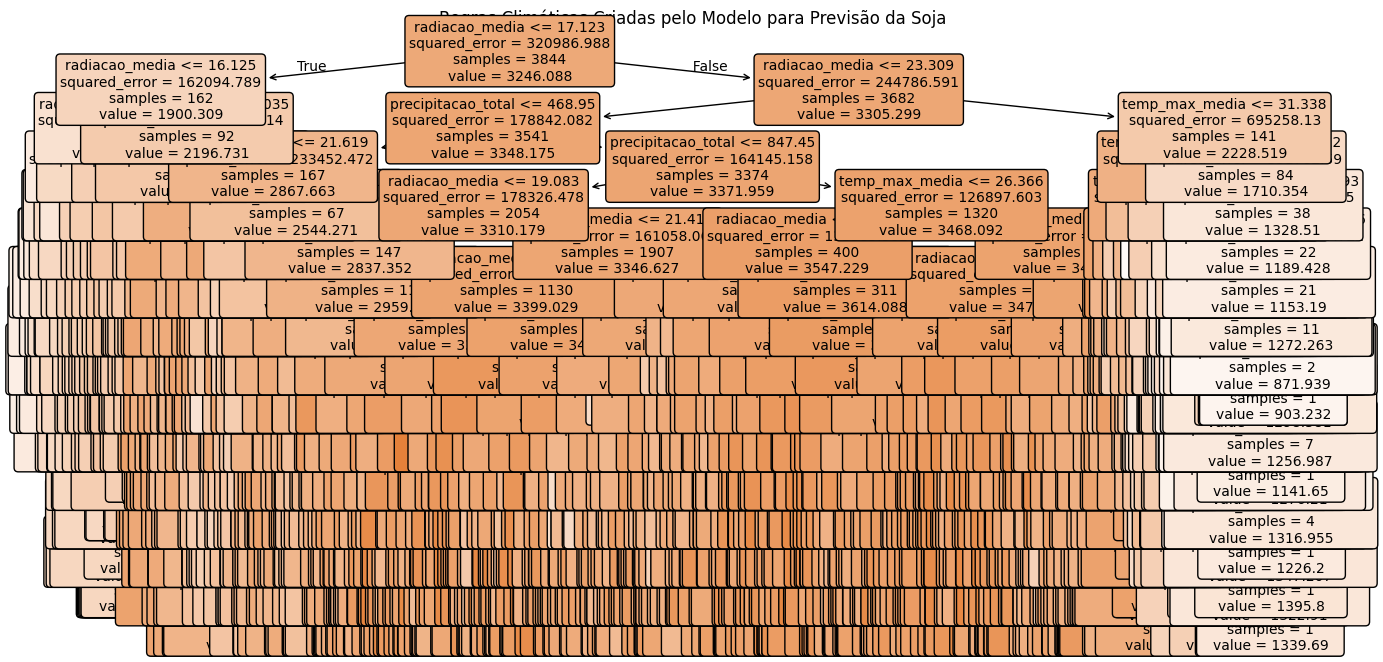

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import root_mean_squared_error, r2_score
import matplotlib.pyplot as plt

# =====================================================================
# VARIÁVEIS
# =====================================================================
# Cenário A: Modelo Completo (Água + Luz + Calor)
colunas_preditoras = ['precipitacao_total', 'radiacao_media', 'temp_max_media']

# Cenário B: Modelo "Cego para Chuva" (Descomente a linha abaixo para testar)
#colunas_preditoras = ['radiacao_media', 'temp_max_media']

# Cenário C: Modelo Apenas de Radiação (Descomente a linha abaixo para testar)
#colunas_preditoras = ['radiacao_media']
# =====================================================================

# 1. Separando as variáveis com base no seu cenário de teste
# (Substitua 'df_clima' pelo nome da sua tabela consolidada)
X = df_clima[colunas_preditoras]
y = df_clima['biomass_grain']

# --- VERIFICAÇÃO DE DADOS VAZIOS PARA EVITAR ERRO DE N_SAMPLES=0 ---
if X.empty or y.empty:
    print("ALERTA: O DataFrame de features (X) ou o de target (y) está vazio. Não é possível treinar o modelo.")
    print(f"X.shape: {X.shape}, y.shape: {y.shape}")
else:
    print(f"Shape de X antes da divisão: {X.shape}")
    print(f"Shape de y antes da divisão: {y.shape}")

    # 2. Divisão clássica de Treino (80%) e Teste (20%)
    # Verificamos também se há amostras suficientes para a divisão
    if len(X) < 2: # É necessário pelo menos 2 amostras para split (1 treino, 1 teste)
        print("ALERTA: Poucas amostras para realizar a divisão de treino e teste. Mínimo de 2 amostras necessárias.")
    else:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # 3. Treinando a Árvore de Regressão
        # Usamos max_depth=3 para podermos visualizar a árvore claramente na tela
        modelo_clima = DecisionTreeRegressor(max_depth=15, random_state=42)
        modelo_clima.fit(X_train, y_train)

        # 4. Avaliando o impacto da sua escolha de variáveis
        previsoes = modelo_clima.predict(X_test)
        rmse = root_mean_squared_error(y_test, previsoes)
        r2 = r2_score(y_test, previsoes)

        print(f"--- RESULTADO DO SEU PROJETO DE ALGORITMO ---")
        print(f"Variáveis utilizadas: {colunas_preditoras}")
        print(f"Erro Médio (RMSE): {rmse:.2f} kg/ha")
        print(f"Poder de Explicação (R²): {r2:.4f} (Quanto mais perto de 1.0, melhor)")

        # 5. Visualizando as regras climáticas que o algoritmo criou
        plt.figure(figsize=(15, 8))
        plot_tree(modelo_clima, feature_names=colunas_preditoras, filled=True, rounded=True, fontsize=10)
        plt.title("Regras Climáticas Criadas pelo Modelo para Previsão da Soja")
        plt.show()

# Random forest

Treinando Random Forest...

 RESULTADO RANDOM FOREST  
Erro Médio de Previsão (RMSE): 395.64 kg/ha
Poder de Explicação do Modelo (R²): 0.5007

Erro Absoluto Médio (MAE): 298.41 kg/ha


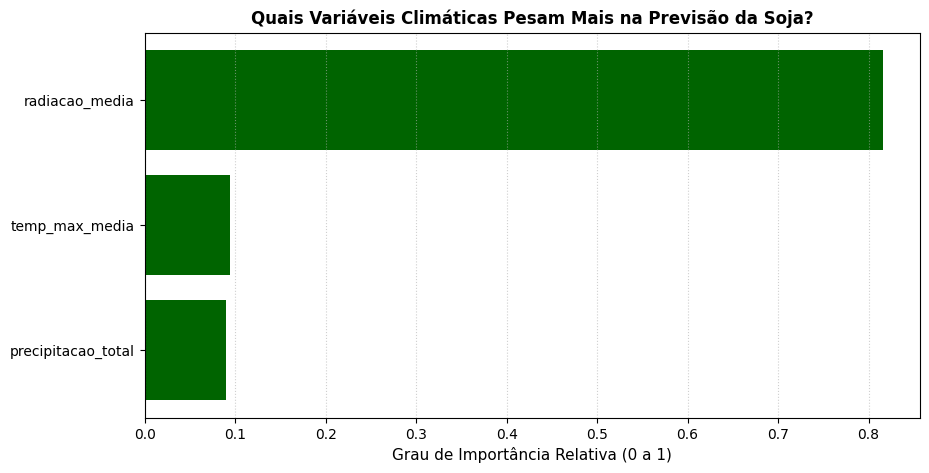

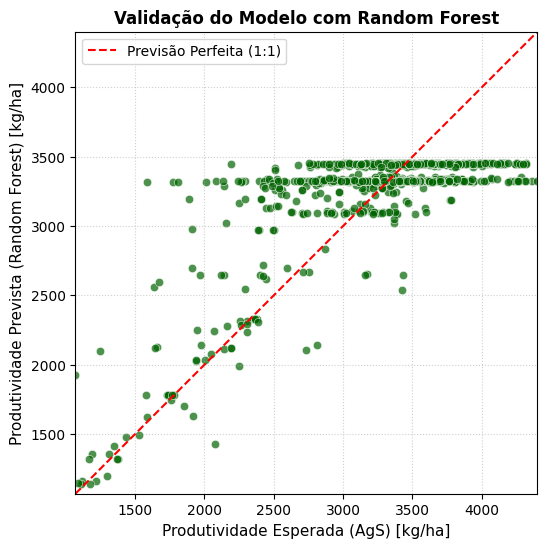

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

print("Treinando Random Forest...")

#colunas_preditoras = ["precipitacao_total", "radiacao_media", "temp_max_media"]
X = df_clima[colunas_preditoras]
y = df_clima["biomass_grain"]

# divisão de treino e teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# n_estimators=100 significa que o algoritmo vai criar 100 árvores diferentes simultaneamente
modelo_floresta = RandomForestRegressor(
    n_estimators=100, max_depth=4, random_state=42
)
modelo_floresta.fit(X_train, y_train)

# Fazendo previsões e calculando as métricas
previsoes_rf = modelo_floresta.predict(X_test)
rmse_rf = root_mean_squared_error(y_test, previsoes_rf)
mae_rf = mean_absolute_error(y_test, previsoes_rf)
r2_rf = r2_score(y_test, previsoes_rf)

print("\n" + "=" * 50)
print(" RESULTADO RANDOM FOREST  ")
print("=" * 50)
print(f"Erro Médio de Previsão (RMSE): {rmse_rf:.2f} kg/ha")
print(f"Poder de Explicação do Modelo (R²): {r2_rf:.4f}")
print("=" * 50 + "\n")
print(f"Erro Absoluto Médio (MAE): {mae_rf:.2f} kg/ha")

# Gráfico de Importância das Variáveis Climáticas
importancias = modelo_floresta.feature_importances_
indices = np.argsort(importancias)

plt.figure(figsize=(10, 5))
plt.barh(
    range(len(indices)),
    importancias[indices],
    color="darkgreen",
    align="center",
)
plt.yticks(range(len(indices)), [colunas_preditoras[i] for i in indices])
plt.xlabel("Grau de Importância Relativa (0 a 1)", fontsize=11)
plt.title(
    "Quais Variáveis Climáticas Pesam Mais na Previsão da Soja?",
    fontsize=12,
    fontweight="bold",
)
plt.grid(axis="x", linestyle=":", alpha=0.6)
plt.show()

# Comparativo de Dispersão (Observado vs. Previsto)
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=previsoes_rf, alpha=0.7, color="darkgreen")

mn, mx = (
    min(y_test.min(), previsoes_rf.min()),
    max(y_test.max(), previsoes_rf.max()),
)
plt.plot(
    [mn, mx],
    [mn, mx],
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Previsão Perfeita (1:1)",
)

plt.xlabel("Produtividade Esperada (AgS) [kg/ha]", fontsize=11)
plt.ylabel("Produtividade Prevista (Random Forest) [kg/ha]", fontsize=11)
plt.title("Validação do Modelo com Random Forest", fontsize=12, fontweight="bold")
plt.xlim(mn, mx)
plt.ylim(mn, mx)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.show()

# Comparação de Modelos


In [ ]:
import os
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor

print("Iniciando . . . ")

crop = "soybean"

# 1. Divisão de treino e teste (80/20)
X_completo = df_clima[["precipitacao_total", "radiacao_media", "temp_max_media"]]
y = df_clima["biomass_grain"]
X_train_comp, X_test_comp, y_train, y_test = train_test_split(
    X_completo, y, test_size=0.2, random_state=42
)

# 2. Definição dos cenários
cenarios = {
    "Cenário A: Completo (Chuva + Luz + Calor)": [
        "precipitacao_total",
        "radiacao_media",
        "temp_max_media",
    ],
    'Cenário B: Sem Chuva (Luz + Calor)': [
        "radiacao_media",
        "temp_max_media",
    ],
    "Cenário C: Potencial (Apenas Luz)": ["radiacao_media"],
}

resultados_lista = []

# 3. Loop automático para processar cada cenário sem estragar os modelos globais
for nome_cenario, colunas in cenarios.items():
    X_train_sub = X_train_comp[colunas]
    X_test_sub = X_test_comp[colunas]

    # --- MODELO 1: ÁRVORE SIMPLES ---
    modelo_arvore_loop = DecisionTreeRegressor(max_depth=15, random_state=42)
    modelo_arvore_loop.fit(X_train_sub, y_train)
    prev_arvore = modelo_arvore_loop.predict(X_test_sub)

    resultados_lista.append(
        {
            "Algoritmo": "Árvore de Regressão (CART)",
            "Cenário": nome_cenario,
            "Variáveis Utilizadas": ", ".join(colunas),
            "Erro Médio (RMSE) [kg/ha]": round(
                root_mean_squared_error(y_test, prev_arvore), 2
            ),
            "Erro Absoluto (MAE) [kg/ha]": round(
                mean_absolute_error(y_test, prev_arvore), 2
            ),
            "R²": round(r2_score(y_test, prev_arvore), 4),
        }
    )

    # --- MODELO 2: RANDOM FOREST ---
    modelo_floresta_loop = RandomForestRegressor(
        n_estimators=100, max_depth=4, random_state=42
    )
    modelo_floresta_loop.fit(X_train_sub, y_train)
    prev_forest = modelo_floresta_loop.predict(X_test_sub)

    resultados_lista.append(
        {
            "Algoritmo": "Random Forest",
            "Cenário": nome_cenario,
            "Variáveis Utilizadas": ", ".join(colunas),
            "Erro Médio (RMSE) [kg/ha]": round(
                root_mean_squared_error(y_test, prev_forest), 2
            ),
            "Erro Absoluto (MAE) [kg/ha]": round(
                mean_absolute_error(y_test, prev_forest), 2
            ),
            "R²": round(r2_score(y_test, prev_forest), 4),
        }
    )

# 4. Criação da tabela de resultados
df_resultados = pd.DataFrame(resultados_lista)

# 5. Exportando para O Drive
pasta_figuras = "drive/MyDrive/MESTRADO/Embrapa/ags_run/outputs/soybean/"
os.makedirs(pasta_figuras, exist_ok=True)
caminho_salvamento = os.path.join(pasta_figuras, "tabela_metamodelos_clima.csv")
df_resultados.to_csv(caminho_salvamento, index=False)

print("\n" + "=" * 60)
print("TABELA COMPARATIVA ")
print("=" * 60)
display(df_resultados)
print("=" * 60)
print(f"Tabela exportada e salva com sucesso em:\n   {caminho_salvamento}")

Iniciando . . . 

TABELA COMPARATIVA 


,Algoritmo,Cenário,Variáveis Utilizadas,Erro Médio (RMSE) [kg/ha],Erro Absoluto (MAE) [kg/ha],R²
0,Árvore de Regressão (CART),Cenário A: Completo (Chuva + Luz + Calor),"precipitacao_total, radiacao_media, temp_max_m...",312.93,206.57,0.6876
1,Random Forest,Cenário A: Completo (Chuva + Luz + Calor),"precipitacao_total, radiacao_media, temp_max_m...",395.64,298.41,0.5007
2,Árvore de Regressão (CART),Cenário B: Sem Chuva (Luz + Calor),"radiacao_media, temp_max_media",318.23,210.49,0.6769
3,Random Forest,Cenário B: Sem Chuva (Luz + Calor),"radiacao_media, temp_max_media",405.81,305.11,0.4747
4,Árvore de Regressão (CART),Cenário C: Potencial (Apenas Luz),radiacao_media,353.96,243.93,0.6003
5,Random Forest,Cenário C: Potencial (Apenas Luz),radiacao_media,432.05,322.12,0.4045


Tabela exportada e salva com sucesso em:
   drive/MyDrive/MESTRADO/Embrapa/ags_run/outputs/soybean/tabela_metamodelos_clima.csv


# Amostragem

In [ ]:
!pip install SALib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 13.0 MB/s eta 0:00:00


Preparando o espaço amostral e calculando Sobol para a Árvore...

📊 ÍNDICES DE SOBOL - ÁRVORE DE REGRESSÃO (CART)


/tmp/ipykernel_4310/1775096763.py:20: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  amostras_clima = saltelli.sample(problema_sobol, 512)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


,Variável,Primeira Ordem (Si),Ordem Total (ST)
0,precipitacao_total,-0.037161,0.131718
1,radiacao_media,0.758123,0.977050
2,temp_max_media,-0.003833,0.186741


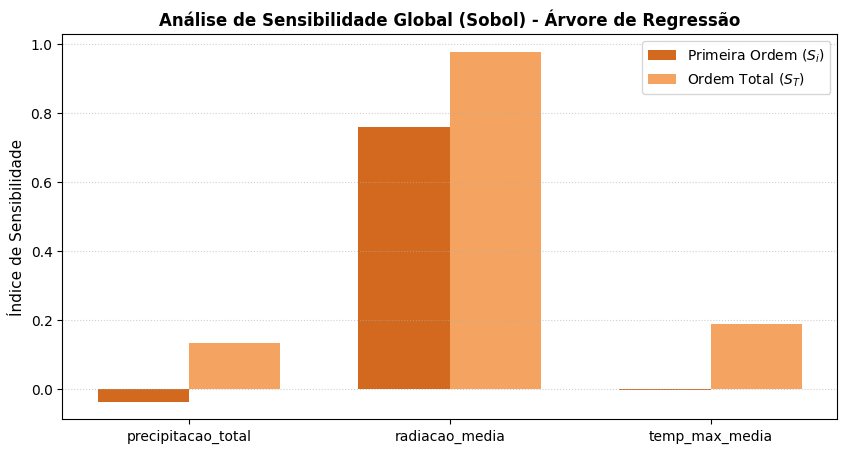

Gráfico da Árvore salvo com sucesso em: drive/MyDrive/MESTRADO/Embrapa/ags_run/outputs/soybean/sobol_arvore_regressao.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from SALib.analyze import sobol
from SALib.sample import saltelli

%pip install SALib --quiet

print("Preparando o espaço amostral e calculando Sobol para a Árvore...")

# 1. Definição do problema usando os limites reais do seu df_clima atual
problema_sobol = {
    "num_vars": len(colunas_preditoras),
    "names": colunas_preditoras,
    "bounds": [[df_clima[col].min(), df_clima[col].max()] for col in colunas_preditoras],
}

# 2. Gerando as combinações teóricas (Mapeamento do Espaço de Entrada)
# N=512 gera pontos suficientes para uma convergência estável dos índices
amostras_clima = saltelli.sample(problema_sobol, 512)

# 3. Fazendo a Árvore (modelo_clima já treinado na célula anterior) prever para essas amostras
previsoes_amostras_arv = modelo_clima.predict(amostras_clima)

# 4. Cálculo dos índices de Sobol
Si_arvore = sobol.analyze(
    problema_sobol, previsoes_amostras_arv, print_to_console=False
)

# 5. Criando a tabela de resultados para o relatório
df_sobol_arvore = pd.DataFrame(
    {
        "Variável": problema_sobol["names"],
        "Primeira Ordem (Si)": Si_arvore["S1"],
        "Ordem Total (ST)": Si_arvore["ST"],
    }
)

print("\n📊 ÍNDICES DE SOBOL - ÁRVORE DE REGRESSÃO (CART)")
display(df_sobol_arvore)

# 6. Plotagem do Gráfico Comparativo de Barras
x_indices = np.arange(len(problema_sobol["names"]))
largura = 0.35

plt.figure(figsize=(10, 5))
plt.bar(
    x_indices - largura / 2,
    Si_arvore["S1"],
    largura,
    label="Primeira Ordem ($S_i$)",
    color="chocolate",
)
plt.bar(
    x_indices + largura / 2,
    Si_arvore["ST"],
    largura,
    label="Ordem Total ($S_T$)",
    color="sandybrown",
)

plt.xticks(x_indices, problema_sobol["names"])
plt.ylabel("Índice de Sensibilidade", fontsize=11)
plt.title("Análise de Sensibilidade Global (Sobol) - Árvore de Regressão", fontsize=12, fontweight="bold")
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.legend()

# Salva automaticamente na pasta de figuras do seu Drive
pasta_figuras = "drive/MyDrive/MESTRADO/Embrapa/ags_run/outputs/soybean/"
os.makedirs(pasta_figuras, exist_ok=True)
path_save_arv = os.path.join(pasta_figuras, "sobol_arvore_regressao.png")

plt.savefig(path_save_arv, dpi=300, bbox_inches="tight")
plt.show()
print(f"Gráfico da Árvore salvo com sucesso em: {path_save_arv}")

Calculando Sobol para o Random Forest baseado nas variáveis ativas: ['precipitacao_total', 'radiacao_media', 'temp_max_media']...


/tmp/ipykernel_4310/1161745548.py:18: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  amostras_clima_dinamicas = saltelli.sample(problema_sobol_dinamico, 512)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(



ÍNDICES DE SOBOL - RANDOM FOREST


,Variável,Primeira Ordem (Si),Ordem Total (ST)
0,precipitacao_total,0.009479,0.026790
1,radiacao_media,0.866693,0.978255
2,temp_max_media,0.032567,0.131970


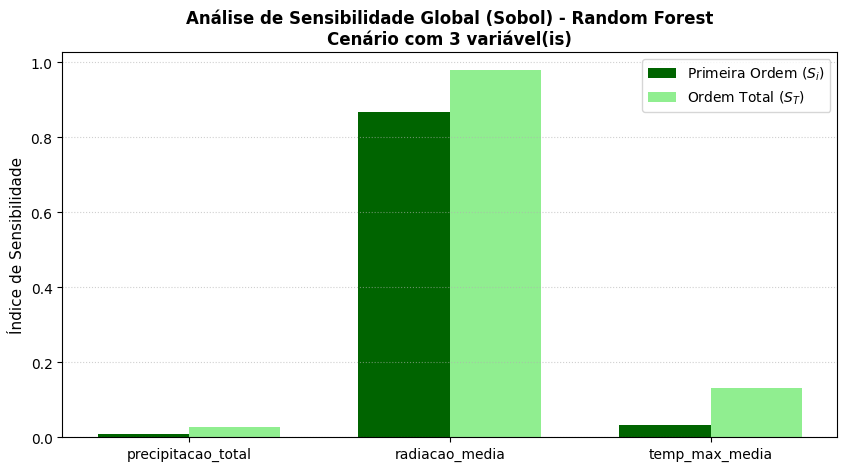

Gráfico da Árvore salvo com sucesso em: drive/MyDrive/MESTRADO/Embrapa/ags_run/outputs/soybean/sobol_arvore_regressao.png


In [ ]:
from SALib.analyze import sobol
from SALib.sample import saltelli
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

print(f"Calculando Sobol para o Random Forest baseado nas variáveis ativas: {colunas_preditoras}...")

# 1. Ajustamos o problema dinamicamente de acordo com o cenário ativo do laboratório
problema_sobol_dinamico = {
    "num_vars": len(colunas_preditoras),
    "names": colunas_preditoras,
    "bounds": [[df_clima[col].min(), df_clima[col].max()] for col in colunas_preditoras],
}

# 2. Geramos as amostras de Saltelli específicas para o cenário atual
amostras_clima_dinamicas = saltelli.sample(problema_sobol_dinamico, 512)

# 3. Agora o predict vai receber exatamente o número de colunas esperado!
previsoes_amostras_rf = modelo_floresta.predict(amostras_clima_dinamicas)

# 4. Cálculo dos índices de Sobol
Si_forest = sobol.analyze(
    problema_sobol_dinamico, previsoes_amostras_rf, print_to_console=False
)

# 5. Criando a tabela de resultados para o relatório
df_sobol_forest = pd.DataFrame(
    {
        "Variável": problema_sobol_dinamico["names"],
        "Primeira Ordem (Si)": Si_forest["S1"],
        "Ordem Total (ST)": Si_forest["ST"],
    }
)

print("\nÍNDICES DE SOBOL - RANDOM FOREST")
display(df_sobol_forest)

# 6. Plotagem do Gráfico Comparativo de Barras Adaptativo
x_indices = np.arange(len(problema_sobol_dinamico["names"]))
largura = 0.35

plt.figure(figsize=(10, 5))
plt.bar(
    x_indices - largura / 2,
    Si_forest["S1"],
    largura,
    label="Primeira Ordem ($S_i$)",
    color="darkgreen",
)
plt.bar(
    x_indices + largura / 2,
    Si_forest["ST"],
    largura,
    label="Ordem Total ($S_T$)",
    color="lightgreen",
)

plt.xticks(x_indices, problema_sobol_dinamico["names"])
plt.ylabel("Índice de Sensibilidade", fontsize=11)
plt.title(f"Análise de Sensibilidade Global (Sobol) - Random Forest\nCenário com {len(colunas_preditoras)} variável(is)", fontsize=12, fontweight="bold")
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.legend()

# Salva na pasta de figuras do seu Drive de forma organizada
pasta_figuras = "drive/MyDrive/MESTRADO/Embrapa/ags_run/outputs/soybean/"
os.makedirs(pasta_figuras, exist_ok=True)
path_save_rf = os.path.join(pasta_figuras, "sobol_arvore_regressao.png")

plt.savefig(path_save_rf, dpi=300, bbox_inches="tight")
plt.show()
print(f"Gráfico da Árvore salvo com sucesso em: {path_save_rf}")

In [ ]:
display(df_bruto.head())

,safra,cultura,município,geocodigo_ibge,regiao,nucleo regional,area total (ha),producao (t),prod_agregada_regional (t),plantio_25%,...,biomass_stemsf,biomass_stemrf,biomass_dstemf,biomass_grainf,biomass_shellf,biomass_gleavesf,biomass_dleavesf,biomass_lbranchf,biomass_dbranchf,sowday
0,01/02,Soja (1ª Safra),Medianeira,4115804,Oeste,Cascavel,11170.0,36866.0,1199450.2,2001-08-17,...,3334.48,175.499,0.0,3961.19,1186.56,172.170,2897.94,0.0,0.0,2001-08-15
1,01/02,Soja (1ª Safra),Vera Cruz do Oeste,4128559,Oeste,Cascavel,11500.0,34500.0,1199450.2,2001-08-17,...,3365.15,177.113,0.0,3828.94,1146.94,152.574,2917.54,0.0,0.0,2001-08-15
2,01/02,Soja (1ª Safra),Braganey,4103354,Oeste,Cascavel,15000.0,46500.0,1199450.2,2001-08-17,...,4141.41,217.969,0.0,4306.91,1290.11,167.005,2903.11,0.0,0.0,2001-08-15
3,01/02,Soja (1ª Safra),Santa Tereza do Oeste,4124020,Oeste,Cascavel,17100.0,53010.0,1199450.2,2001-08-17,...,3831.83,201.675,0.0,4257.25,1275.24,172.588,2897.53,0.0,0.0,2001-08-15
4,01/02,Soja (1ª Safra),Matelândia,4115606,Oeste,Cascavel,9500.0,27550.0,1199450.2,2001-08-17,...,3331.05,175.319,0.0,3959.57,1186.07,171.176,2898.94,0.0,0.0,2001-08-15
